In [3]:
import pandas as pd

In [41]:
cibersortx_df = pd.read_csv("/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/CIBERSORTx_TPM_Counts_Results.csv", index_col=0)

In [42]:
cibersortx_df['Phase'] = cibersortx_df.index.to_series().str.extract(r'(Phase\d+)', expand=False)

In [45]:

cibersortx_df.index = cibersortx_df.index.str.replace(r'PPMI-Phase\d?-IR\d?\.', '', regex=True).str.replace('-', '.', regex=False)

In [46]:
cibersortx_df.head()

,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Phase
Mixture,,,,,,,,,,,,,,,,,,,,,
3585.BL.PP0015.6635.5104.SL.0731,0.015220,0.000000,0.002108,0.000000,0.199560,0.041053,0.018642,0,0.0,0.0,...,0.0,0.003046,0.002666,0.0,0.000000,0.395394,0,0.753614,0.665328,Phase2
51302.V06.0003394657.5104.SL.2770,0.014267,0.004127,0.000000,0.038765,0.180422,0.124115,0.031841,0,0.0,0.0,...,0.0,0.008066,0.000000,0.0,0.000000,0.317446,0,0.690453,0.731571,Phase2
3003.V02.PP0016.6882.5104.SL.3254,0.026492,0.002021,0.000000,0.057758,0.148165,0.046548,0.023583,0,0.0,0.0,...,0.0,0.000173,0.020765,0.0,0.000000,0.312311,0,0.684196,0.736250,Phase2
3569.V06.0003176244.5104.SL.0622,0.041687,0.074861,0.000000,0.066329,0.244572,0.070129,0.021952,0,0.0,0.0,...,0.0,0.001532,0.007638,0.0,0.000000,0.267723,0,0.677385,0.749972,Phase1
41373.BL.0003105672.5104.SL.4865,0.011150,0.002410,0.000200,0.094310,0.254828,0.000000,0.026709,0,0.0,0.0,...,0.0,0.006984,0.000000,0.0,0.009922,0.234529,0,0.679904,0.745633,Phase2


In [7]:
import anndata as ad
ppmi_adata = ad.read_h5ad("/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/ppmi_adata.h5ad")
ppmi_adata_df = ppmi_adata.to_df()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.

In [49]:
cibersortx_df = cibersortx_df.join(ppmi_adata.obs[['Diagnosis', 'Visit', 'Gender', 'Genetic_Group', 'Age_Group']])

ValueError: columns overlap but no suffix specified: Index(['Diagnosis', 'Visit', 'Gender', 'Genetic_Group', 'Age_Group'], dtype='object')

In [50]:
cibersortx_df.head()

,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Neutrophils,P-value,Correlation,RMSE,Phase,Diagnosis,Visit,Gender,Genetic_Group,Age_Group
Mixture,,,,,,,,,,,,,,,,,,,,,
3585.BL.PP0015.6635.5104.SL.0731,0.015220,0.000000,0.002108,0.000000,0.199560,0.041053,0.018642,0,0.0,0.0,...,0.395394,0,0.753614,0.665328,Phase2,PD,BL,Male,SRDC,30-50
51302.V06.0003394657.5104.SL.2770,0.014267,0.004127,0.000000,0.038765,0.180422,0.124115,0.031841,0,0.0,0.0,...,0.317446,0,0.690453,0.731571,Phase2,Genetic Cohort,V06,Female,LRRK2,50-70
3003.V02.PP0016.6882.5104.SL.3254,0.026492,0.002021,0.000000,0.057758,0.148165,0.046548,0.023583,0,0.0,0.0,...,0.312311,0,0.684196,0.736250,Phase2,PD,V02,Female,SRDC,50-70
3569.V06.0003176244.5104.SL.0622,0.041687,0.074861,0.000000,0.066329,0.244572,0.070129,0.021952,0,0.0,0.0,...,0.267723,0,0.677385,0.749972,Phase1,Control,V06,Female,None,30-50
41373.BL.0003105672.5104.SL.4865,0.011150,0.002410,0.000200,0.094310,0.254828,0.000000,0.026709,0,0.0,0.0,...,0.234529,0,0.679904,0.745633,Phase2,Genetic Registry,BL,Female,Unknown,NaN


/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_21737/1644656276.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cibersortx_df_grouped = cibersortx_df_phase_1.groupby('Diagnosis')[cell_types].mean()


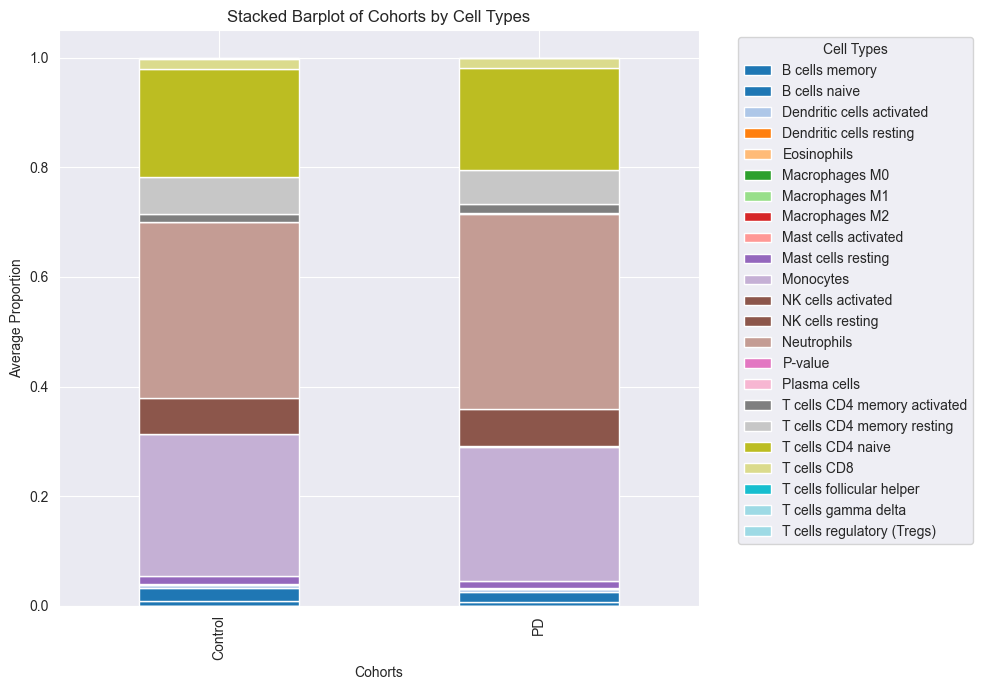

In [60]:
import matplotlib.pyplot as plt

exclude_cols = ['P-Value', 'Correlation', 'RMSE']

cibersortx_df_phase_1 = cibersortx_df[cibersortx_df['Phase'] == 'Phase1']
cibersortx_df_phase_1 = cibersortx_df_phase_1[cibersortx_df_phase_1['Diagnosis'].isin(['PD', 'Control'])]
cibersortx_df_phase_1['Diagnosis'] = cibersortx_df_phase_1['Diagnosis'].cat.remove_unused_categories()

cell_types = cibersortx_df_phase_1.columns.difference(exclude_cols + ['Diagnosis', 'Visit', 'Gender', 'Genetic_Group', 'Age_Group', 'Phase'])
cibersortx_df_grouped = cibersortx_df_phase_1.groupby('Diagnosis')[cell_types].mean()

cibersortx_df_grouped.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='tab20')
plt.title('Stacked Barplot of Cohorts by Cell Types')
plt.ylabel('Average Proportion')
plt.xlabel('Cohorts')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [61]:
cibersortx_df_phase_1.shape

(1565, 31)

In [62]:
cibersortx_df.shape

(4756, 31)

/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


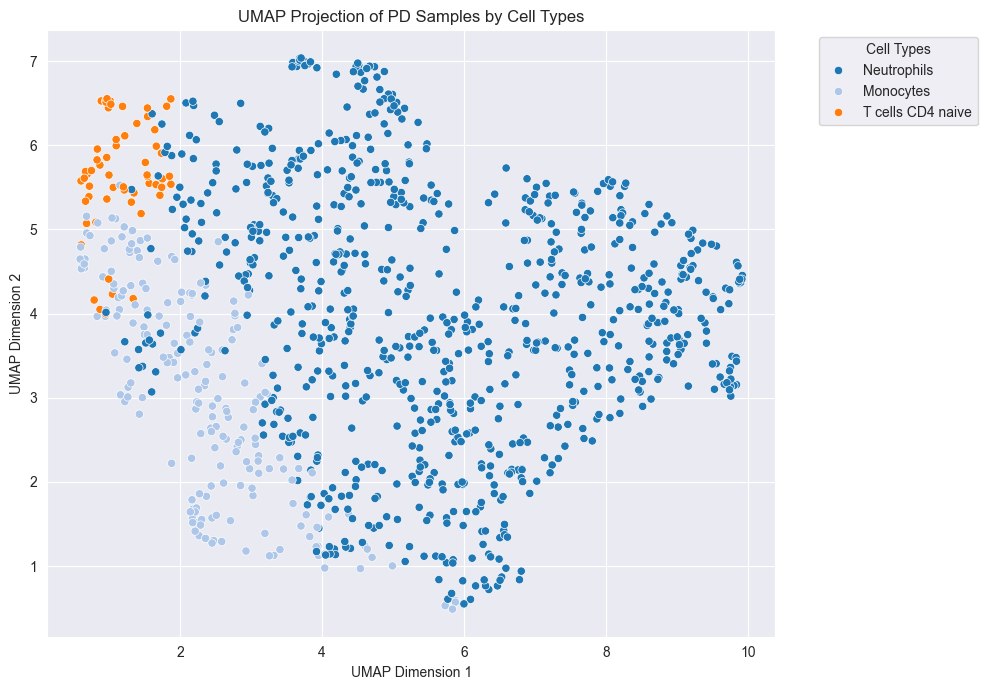

In [64]:
umap = UMAP(n_components=2, random_state=42)
umap_embedding = umap.fit_transform(cibersortx_df_phase_1[cibersortx_df_phase_1['Diagnosis'] == 'PD']
                                    .drop(['Diagnosis', 'Visit', 'Gender', 'Genetic_Group', 'Age_Group', 'Phase'], axis=1))

umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'],
                       index=cibersortx_df_phase_1[cibersortx_df_phase_1['Diagnosis'] == 'PD'].index)

umap_df['Cell_Type'] = cibersortx_df_phase_1.loc[cibersortx_df_phase_1['Diagnosis'] == 'PD', cell_types].idxmax(axis=1)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Cell_Type', palette='tab20')
plt.title('UMAP Projection of PD Samples by Cell Types')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


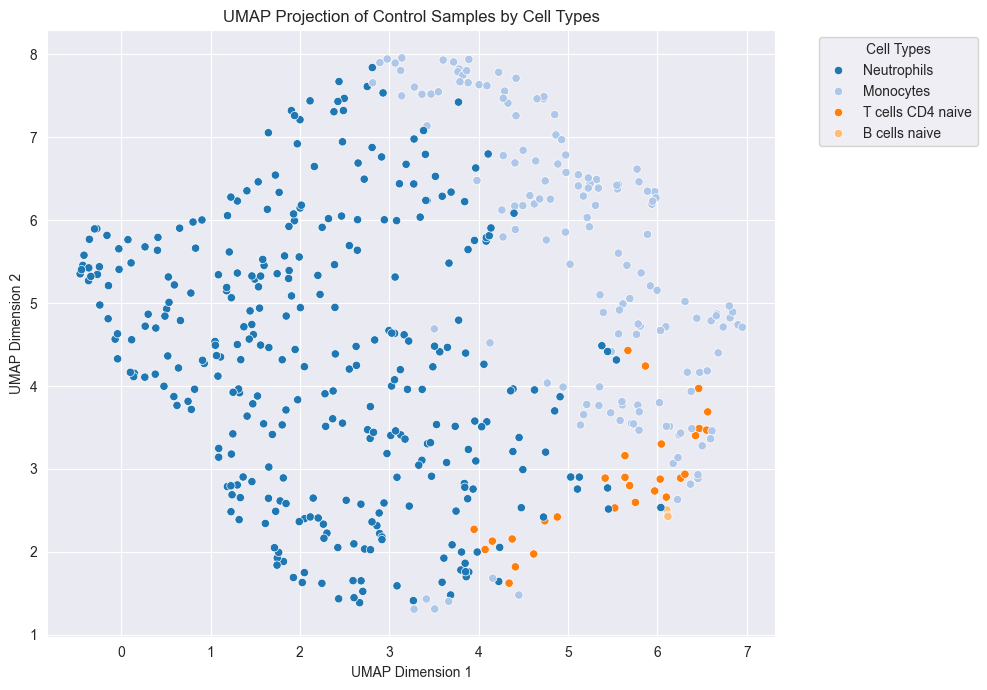

In [65]:
import seaborn.sns as sns
umap_embedding_control = umap.fit_transform(cibersortx_df_phase_1[cibersortx_df_phase_1['Diagnosis'] == 'Control']
                                            .drop(['Diagnosis', 'Visit', 'Gender', 'Genetic_Group', 'Age_Group', 'Phase'], axis=1))

umap_df_control = pd.DataFrame(umap_embedding_control, columns=['UMAP1', 'UMAP2'],
                               index=cibersortx_df_phase_1[cibersortx_df_phase_1['Diagnosis'] == 'Control'].index)

umap_df_control['Cell_Type'] = cibersortx_df_phase_1.loc[cibersortx_df_phase_1['Diagnosis'] == 'Control', cell_types].idxmax(axis=1)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=umap_df_control, x='UMAP1', y='UMAP2', hue='Cell_Type', palette='tab20')
plt.title('UMAP Projection of Control Samples by Cell Types')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [71]:
tmp_df = pd.read_csv("/Volumes/Elements/quant/PPMI_TPM_LM22_Compatible.txt", sep="\t", index_col=0)

In [72]:
tmp_df.head()

,PPMI-Phase2-IR3.3585.BL.PP0015-6635.5104-SL-0731,PPMI-Phase2-IR3.51302.V06.0003394657.5104-SL-2770,PPMI-Phase2-IR3.3003.V02.PP0016-6882.5104-SL-3254,PPMI-Phase1-IR3.3569.V06.0003176244.5104-SL-0622,PPMI-Phase2-IR3.41373.BL.0003105672.5104-SL-4865,PPMI-Phase2-IR3.4127.V04.0003181699.5104-SL-3588,PPMI-Phase2-IR3.40612.V06.0003146372.5104-SL-4142,PPMI-Phase1-IR3.4096.V08.0000965890.5104-SL-0787,PPMI-Phase1-IR3.3132.V06.0000339809.5104-SL-1125,PPMI-Phase1-IR3.3952.V06.0003169249.5104-SL-0499,...,PPMI-Phase1-IR3.4059.BL.PP0015-8053.5104-SL-0465,PPMI-Phase2-IR3.3572.V08.PP0047-6379.5104-SL-1315,PPMI-Phase2-IR3.41284.V02.0001131780.5104-SL-4821,PPMI-Phase2-IR3.40725.V02.0000367669.5104-SL-4134,PPMI-Phase1-IR3.65006.BL.0003195585.5104-SL-1811,PPMI-Phase1-IR3.4082.V04.0003288272.5104-SL-1339,PPMI-Phase2-IR3.58221.BL.0003394612.5104-SL-3968,PPMI-Phase2-IR3.3207.V02.PP0013-2061.5104-SL-3977,PPMI-Phase2-IR3.3161.V06.0003136824.5104-SL-0869,PPMI-Phase2-IR3.40530.V06.0003122154.5104-SL-4113
Name,,,,,,,,,,,,,,,,,,,,,
CD40LG,3.182610,5.513790,5.285950,6.116400,4.289300,4.172750,4.153450,3.121420,3.632900,2.068800,...,4.058550,2.672750,4.170210,3.838540,1.325300,3.527160,4.129090,5.030570,3.285130,2.429200
GPC4,0.050669,0.008158,0.077459,0.310241,0.066191,0.081537,0.023205,0.368389,0.071648,0.035166,...,0.020716,0.055401,0.025971,0.010899,0.039227,0.030911,0.014957,0.123617,0.829659,0.025250
SH2D1A,9.534330,15.135000,13.769500,16.179300,9.902470,11.633100,7.596000,7.033490,7.650720,5.493750,...,8.670690,7.876230,13.334000,7.705020,6.279190,8.523710,13.004100,13.736000,2.378520,5.624150
HMGB3P30,0.160670,0.000000,0.000000,0.397918,0.000000,0.000000,0.000000,0.536392,0.000000,0.018690,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076060,0.666452,0.000000
FOXP3,0.073834,0.029189,0.094348,0.442012,0.084537,0.100786,0.061944,0.347677,0.333273,0.021127,...,0.075078,0.035721,0.041238,0.101918,0.003461,0.115174,0.050679,0.154063,0.361426,0.420163


In [77]:
monocyte_markers = ["CD86", "CD163", "LYZ", "CSF1R", "ITGAM", "CD68", "MS4A4A", "MRC1"]
available_markers = [gene for gene in monocyte_markers if gene in tmp_df.index]

print("Available markers:", available_markers)

Available markers: ['CD86', 'CD68']


In [86]:
print(cibersortx_df_phase_1.columns)

Index(['B cells naive', 'B cells memory', 'Plasma cells', 'T cells CD8',
       'T cells CD4 naive', 'T cells CD4 memory resting',
       'T cells CD4 memory activated', 'T cells follicular helper',
       'T cells regulatory (Tregs)', 'T cells gamma delta', 'NK cells resting',
       'NK cells activated', 'Monocytes', 'Macrophages M0', 'Macrophages M1',
       'Macrophages M2', 'Dendritic cells resting',
       'Dendritic cells activated', 'Mast cells resting',
       'Mast cells activated', 'Eosinophils', 'Neutrophils', 'P-value',
       'Correlation', 'RMSE', 'Phase', 'Diagnosis', 'Visit', 'Gender',
       'Genetic_Group', 'Age_Group'],
      dtype='object')


In [83]:
tmp_df.head()

,PPMI-Phase2-IR3.3585.BL.PP0015-6635.5104-SL-0731,PPMI-Phase2-IR3.51302.V06.0003394657.5104-SL-2770,PPMI-Phase2-IR3.3003.V02.PP0016-6882.5104-SL-3254,PPMI-Phase1-IR3.3569.V06.0003176244.5104-SL-0622,PPMI-Phase2-IR3.41373.BL.0003105672.5104-SL-4865,PPMI-Phase2-IR3.4127.V04.0003181699.5104-SL-3588,PPMI-Phase2-IR3.40612.V06.0003146372.5104-SL-4142,PPMI-Phase1-IR3.4096.V08.0000965890.5104-SL-0787,PPMI-Phase1-IR3.3132.V06.0000339809.5104-SL-1125,PPMI-Phase1-IR3.3952.V06.0003169249.5104-SL-0499,...,PPMI-Phase1-IR3.4059.BL.PP0015-8053.5104-SL-0465,PPMI-Phase2-IR3.3572.V08.PP0047-6379.5104-SL-1315,PPMI-Phase2-IR3.41284.V02.0001131780.5104-SL-4821,PPMI-Phase2-IR3.40725.V02.0000367669.5104-SL-4134,PPMI-Phase1-IR3.65006.BL.0003195585.5104-SL-1811,PPMI-Phase1-IR3.4082.V04.0003288272.5104-SL-1339,PPMI-Phase2-IR3.58221.BL.0003394612.5104-SL-3968,PPMI-Phase2-IR3.3207.V02.PP0013-2061.5104-SL-3977,PPMI-Phase2-IR3.3161.V06.0003136824.5104-SL-0869,PPMI-Phase2-IR3.40530.V06.0003122154.5104-SL-4113
Name,,,,,,,,,,,,,,,,,,,,,
CD40LG,3.182610,5.513790,5.285950,6.116400,4.289300,4.172750,4.153450,3.121420,3.632900,2.068800,...,4.058550,2.672750,4.170210,3.838540,1.325300,3.527160,4.129090,5.030570,3.285130,2.429200
GPC4,0.050669,0.008158,0.077459,0.310241,0.066191,0.081537,0.023205,0.368389,0.071648,0.035166,...,0.020716,0.055401,0.025971,0.010899,0.039227,0.030911,0.014957,0.123617,0.829659,0.025250
SH2D1A,9.534330,15.135000,13.769500,16.179300,9.902470,11.633100,7.596000,7.033490,7.650720,5.493750,...,8.670690,7.876230,13.334000,7.705020,6.279190,8.523710,13.004100,13.736000,2.378520,5.624150
HMGB3P30,0.160670,0.000000,0.000000,0.397918,0.000000,0.000000,0.000000,0.536392,0.000000,0.018690,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076060,0.666452,0.000000
FOXP3,0.073834,0.029189,0.094348,0.442012,0.084537,0.100786,0.061944,0.347677,0.333273,0.021127,...,0.075078,0.035721,0.041238,0.101918,0.003461,0.115174,0.050679,0.154063,0.361426,0.420163


In [87]:
import pandas as pd
import scipy.stats

# Assuming:
# - cibersort_results: DataFrame where ROWS are samples, COLUMNS include cell types
# - tpm_matrix: DataFrame where COLUMNS are samples, ROWS are genes

# Step 1: Verify and align sample IDs
common_samples = set(cibersortx_df_phase_1.index) & set(tmp_df.columns)
if not common_samples:
    raise ValueError("No matching sample IDs between CIBERSORTx results and TPM matrix!")

print(f"Found {len(common_samples)} common samples")

# Step 2: Try multiple monocyte markers
markers_to_test = ["CD14", "CD163", "CD86", "LYZ", "CSF1R", "ITGAM"]
available_markers = [m for m in markers_to_test if m in tmp_df.index]

if not available_markers:
    raise ValueError("None of the monocyte markers found in TPM matrix!")

# Step 3: Calculate correlations for available markers
results = []
for marker in available_markers:
    # Get aligned data
    monocytes = cibersortx_df_phase_1.loc[common_samples, "Monocytes"]
    marker_exp = tmp_df.loc[marker, common_samples]

    # Calculate correlation
    r, p = scipy.stats.pearsonr(monocytes, marker_exp)
    results.append((marker, r, p))
    print(f"Monocytes vs. {marker}: r = {r:.3f}, p = {p:.4f}")

# Convert results to DataFrame for easy viewing
corr_results = pd.DataFrame(results, columns=["Marker", "Correlation", "p-value"])
print("\nSummary of marker correlations:")
print(corr_results.sort_values("Correlation", ascending=False))

ValueError: No matching sample IDs between CIBERSORTx results and TPM matrix!

In [66]:
cibersortx_df_phase_1["Monocytes"]

Mixture
3569.V06.0003176244.5104.SL.0622     0.127532
4096.V08.0000965890.5104.SL.0787     0.149297
3132.V06.0000339809.5104.SL.1125     0.265233
3952.V06.0003169249.5104.SL.0499     0.198614
3558.V04.PP0017.6855.5104.SL.1949    0.239506
                                       ...   
3280.V08.0000302253.5104.SL.1861     0.184134
3587.V08.0000425733.5104.SL.0810     0.260092
4070.BL.PP0015.8085.5104.SL.0441     0.295156
4059.BL.PP0015.8053.5104.SL.0465     0.272617
4082.V04.0003288272.5104.SL.1339     0.223010
Name: Monocytes, Length: 1565, dtype: float64